
Acurácia: 1.00

Pesos finais: [-0.6962546   2.66950714 -4.29268006]


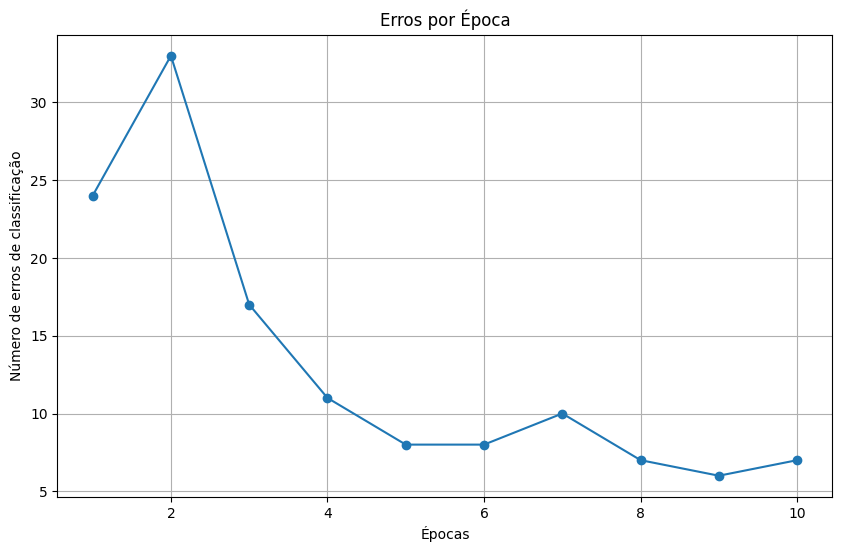

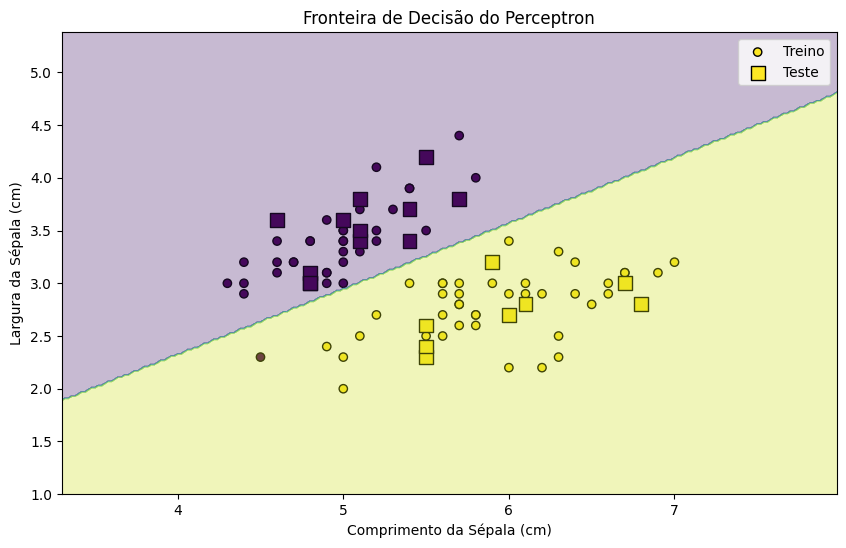

In [5]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

class Perceptron:
    """
    Implementação do algoritmo Perceptron para classificação binária.
    
    Parâmetros:
    -----------
    taxa_aprendizado : float, default=0.01
        Taxa de aprendizado (entre 0.0 e 1.0)
    n_epocas : int, default=50
        Número de passagens sobre o conjunto de treinamento
    random_state : int, default=None
        Semente para o gerador de números aleatórios
        
    Atributos:
    ----------
    pesos : array 1D
        Pesos após o ajuste
    erros : list
        Número de classificações incorretas em cada época
    """
    
    def __init__(self, taxa_aprendizado=0.01, n_epocas=50, random_state=None):
        self.taxa_aprendizado = taxa_aprendizado
        self.n_epocas = n_epocas
        self.random_state = random_state
        np.random.seed(random_state)
    
    def fit(self, X, y):
        """
        Ajusta o modelo aos dados de treinamento.
        
        Parâmetros:
        -----------
        X : array-like, shape = [n_amostras, n_caracteristicas]
            Vetores de treinamento, onde n_amostras é o número de amostras e
            n_caracteristicas é o número de características.
        y : array-like, shape = [n_amostras]
            Valores alvo.
            
        Retorna:
        --------
        self : object
        """
        # Inicializa os pesos com valores pequenos aleatórios
        self.pesos = np.random.rand(X.shape[1] + 1) * 0.01
        
        # Lista para armazenar os erros em cada época
        self.erros = []
        
        # Adiciona o bias (termo de intercepção)
        X_com_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        
        for _ in range(self.n_epocas):
            erros = 0
            for xi, target in zip(X_com_bias, y):
                # Calcula a saída do perceptron
                saida = self.funcao_ativacao(np.dot(xi, self.pesos))
                
                # Atualiza os pesos
                update = self.taxa_aprendizado * (target - saida)
                self.pesos += update * xi
                
                # Conta os erros
                if target != saida:
                    erros += 1
            self.erros.append(erros)
        
        return self
    
    def funcao_ativacao(self, x):
        """
        Função degrau (step function) para ativação.
        """
        return np.where(x >= 0, 1, 0)
    
    def predict(self, X):
        """
        Prediz os rótulos de classe para amostras em X.
        
        Parâmetros:
        -----------
        X : array-like, shape = [n_amostras, n_caracteristicas]
            
        Retorna:
        --------
        classe_predita : array, shape = [n_amostras]
            Rótulos de classe preditos
        """
        # Adiciona o bias
        X_com_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        return self.funcao_ativacao(np.dot(X_com_bias, self.pesos))
    
    def plot_erros_por_epoca(self):
        """
        Plota o número de erros de classificação por época.
        """
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.erros) + 1), self.erros, marker='o')
        plt.xlabel('Épocas')
        plt.ylabel('Número de erros de classificação')
        plt.title('Erros por Época')
        plt.grid()
        plt.show()

# Exemplo de uso completo
if __name__ == "__main__":
    # 1. Carrega o dataset Iris (apenas duas classes para classificação binária)
    iris = load_iris()
    X = iris.data[:100, :2]  # Usamos apenas as duas primeiras características e 100 primeiras amostras
    y = iris.target[:100]    # Apenas duas classes (0 e 1)
    
    # 2. Divide em conjunto de treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    # 3. Cria e treina o perceptron
    ppn = Perceptron(taxa_aprendizado=0.1, n_epocas=10, random_state=42)
    ppn.fit(X_train, y_train)
    
    # 4. Faz previsões
    y_pred = ppn.predict(X_test)
    
    # 5. Calcula a acurácia
    acuracia = accuracy_score(y_test, y_pred)
    print(f'\nAcurácia: {acuracia:.2f}')
    
    # 6. Mostra os pesos finais
    print(f'\nPesos finais: {ppn.pesos}')
    
    # 7. Plota a convergência do treinamento
    ppn.plot_erros_por_epoca()
    
    # 8. Plota a fronteira de decisão (apenas para 2 características)
    plt.figure(figsize=(10, 6))
    
    # Plota os dados de treinamento
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', 
                edgecolors='k', label='Treino')
    # Plota os dados de teste
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', 
                marker='s', s=100, edgecolors='k', label='Teste')
    
    # Calcula a fronteira de decisão
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                          np.arange(x2_min, x2_max, 0.02))
    
    Z = ppn.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap='viridis')
    plt.xlabel('Comprimento da Sépala (cm)')
    plt.ylabel('Largura da Sépala (cm)')
    plt.title('Fronteira de Decisão do Perceptron')
    plt.legend()
    plt.show()